In [22]:
#URL : https://www.kaggle.com/competitions/tpu-getting-started/overview

In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping


In [25]:
print(tf.__version__)

2.19.0


In [26]:
DATA_PATH = "/content/drive/MyDrive/Machine & Deep Learning/tpu-getting-started"
IMAGE_SIZE = [256,256]
BATCH_SIZE = 32

In [27]:
def preprocess_image(raw_image):
    image = tf.image.decode_jpeg(raw_image,channels = 3)
    image = tf.cast(image,tf.float32) / 255.0
    image = tf.image.resize(image,IMAGE_SIZE)
    return image
def read_labeled_tfrecord(row_data):
    labeled_tfrec_format = {
        "image" : tf.io.FixedLenFeature([],tf.string),
        "class" : tf.io.FixedLenFeature([],tf.int64)
    }
    example = tf.io.parse_single_example(row_data,labeled_tfrec_format)
    image = preprocess_image(example['image'])
    label = tf.cast(example['class'],tf.int64)
    return image,label

def read_unlabeled_tfrecord(row_data):
    unlabeled_tfrec_format = {
        "image" : tf.io.FixedLenFeature(row_data,tf.string),
        "id" : tf.io.FixedLenFeature(row_data,tf.string)
    }
    example = tf.io.parse_single_example(row_data,unlabeled_tfrec_format)
    image = preprocess_image(example['image'])
    id = tf.cast(example['id'],tf.string)
    return image,id

def load_dataset(filenames, labeled=True, ordered=False):

    ignore_order = tf.data.Options()
    if ordered == False:
        ignore_order.experimental_deterministic = False

    dataset = tf.data.TFRecordDataset(filenames)
    dataset = dataset.with_options(ignore_order)
    dataset = dataset.map(read_labeled_tfrecord if labeled else read_unlabeled_tfrecord)
    return dataset

In [28]:
def get_training_dataset():
    dataset1 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-512x512/train/*.tfrec'), labeled=True)
    dataset2 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-331x331/train/*.tfrec'), labeled=True)
    dataset3 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-224x224/train/*.tfrec'), labeled=True)
    dataset4 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-192x192/train/*.tfrec'), labeled=True)

    dataset = dataset1.concatenate(dataset2)
    dataset = dataset.concatenate(dataset3)
    dataset = dataset.concatenate(dataset4)

    dataset = dataset.repeat()        # sửa typo
    dataset = dataset.shuffle(50)
    dataset = dataset.batch(BATCH_SIZE)

    return dataset
def get_validation_dataset():
    dataset1 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-512x512/val/*.tfrec'), labeled=True)
    dataset2 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-331x331/val/*.tfrec'), labeled=True)
    dataset3 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-224x224/val/*.tfrec'), labeled=True)
    dataset4 = load_dataset(tf.io.gfile.glob(DATA_PATH + '/tfrecords-jpeg-192x192/val/*.tfrec'), labeled=True)
    
    dataset = dataset1.concatenate(dataset2)
    dataset = dataset.concatenate(dataset3)
    dataset = dataset.concatenate(dataset4)
    
    dataset = dataset.repeat()        # sửa typo
    dataset = dataset.shuffle(50)
    dataset = dataset.batch(BATCH_SIZE)

    return dataset

In [29]:
train_data = get_training_dataset()
valid_data = get_validation_dataset()

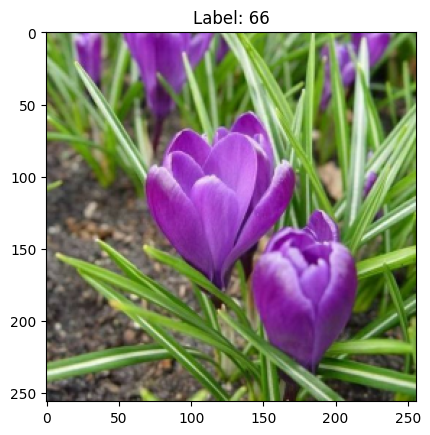

In [30]:
import matplotlib.pyplot as plt

for x, y in valid_data.take(1):
    plt.imshow(x[0].numpy())
    plt.title(f"Label: {y[0].numpy()}")
    plt.show()

In [ ]:
model = keras.Sequential([
    layers.Input(shape = (IMAGE_SIZE[0],IMAGE_SIZE[0],3)),
    layers.RandomRotation(0.36),
    layers.RandomZoom(0.36),
    layers.RandomTranslation(0.36,0.36),
    
    layers.Conv2D(filters = 32,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.Conv2D(filters = 32,kernel_size = 3,strides = 1,padding = 'same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dropout(0.36),
    layers.Dense(units = 512,activation = 'relu'),
    layers.Dense(units = 136,activation = 'softmax')
])

In [34]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['sparse_categorical_accuracy']
)

In [36]:
history = model.fit(
    train_data,
    validation_data = valid_data,
    epochs = 25,
    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 7, restore_best_weights = True)]
)

Epoch 1/25


KeyboardInterrupt: 